Shape of DataFrame after dropping NaNs in 'MIS_Status': (895641, 18)
=== Decision Tree ===
Accuracy: 0.9288
Recall: 0.9569
Precision: 0.9566
F1 Score. 0.9567

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.80      0.80     31704
           1       0.96      0.96      0.96    147425

    accuracy                           0.93    179129
   macro avg       0.88      0.88      0.88    179129
weighted avg       0.93      0.93      0.93    179129



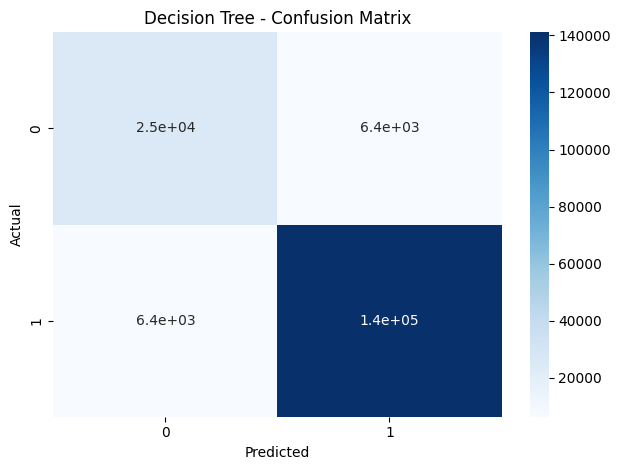

               Feature  Importance
2                 Term    0.532148
1         ApprovalYear    0.144747
12            SBA_Appv    0.041953
0                NAICS    0.032345
10   DisbursementGross    0.032176
3                NoEmp    0.021493
11              GrAppv    0.020856
7        FranchiseCode    0.016921
67        BankState_CA    0.013664
6          RetainedJob    0.012778
5            CreateJob    0.009629
4             NewExist    0.006238
8           UrbanRural    0.005171
16            State_CA    0.005083
9               LowDoc    0.004261
71        BankState_DE    0.004083
92        BankState_NC    0.003561
103       BankState_PA    0.003373
79        BankState_IL    0.003244
107       BankState_SD    0.003188


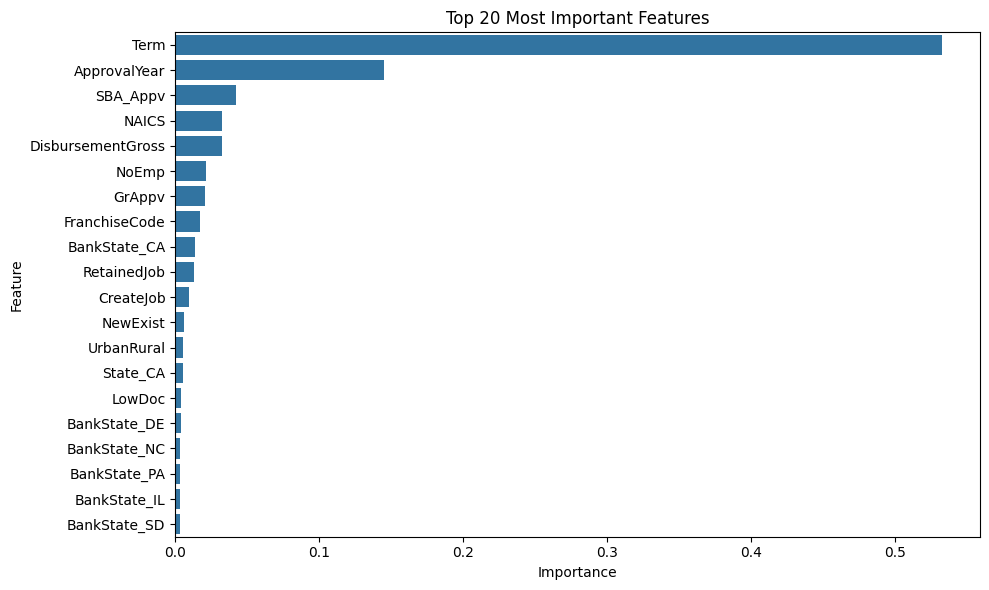

[LightGBM] [Info] Number of positive: 590732, number of negative: 125780
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.117802 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2322
[LightGBM] [Info] Number of data points in the train set: 716512, number of used features: 114
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.824455 -> initscore=1.546828
[LightGBM] [Info] Start training from score 1.546828
=== LGBM ===
Accuracy: 0.9469
Recall: 0.9757
Precision: 0.9605
F1 Score: 0.9680

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.81      0.84     31704
           1       0.96      0.98      0.97    147425

    accuracy                           0.95    179129
   macro avg       0.92      0.89      0.91    179129
weighted avg       0.95      0.95      0.95    179129



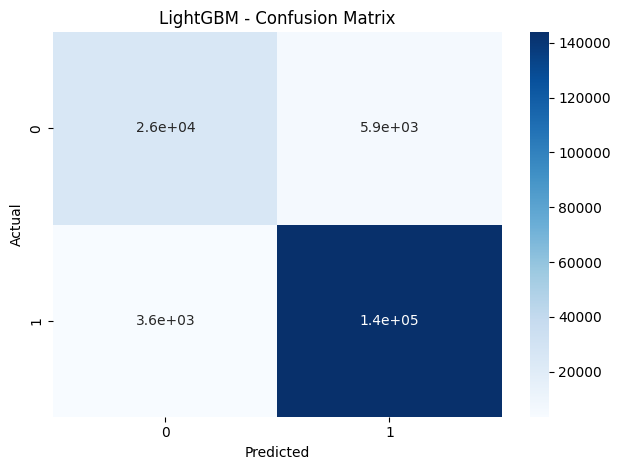

Decision Tree ROC-AUC: 0.8775
LightGBM ROC-AUC: 0.9772


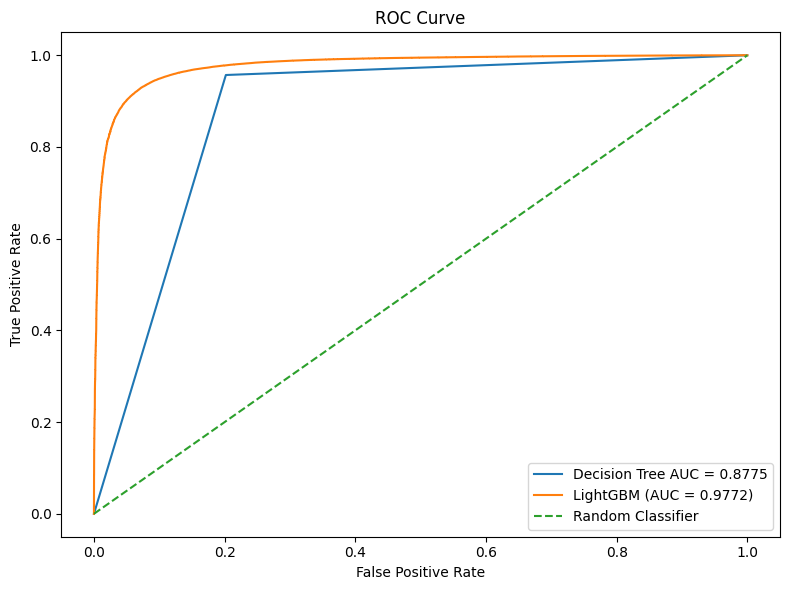

<Figure size 1000x600 with 0 Axes>

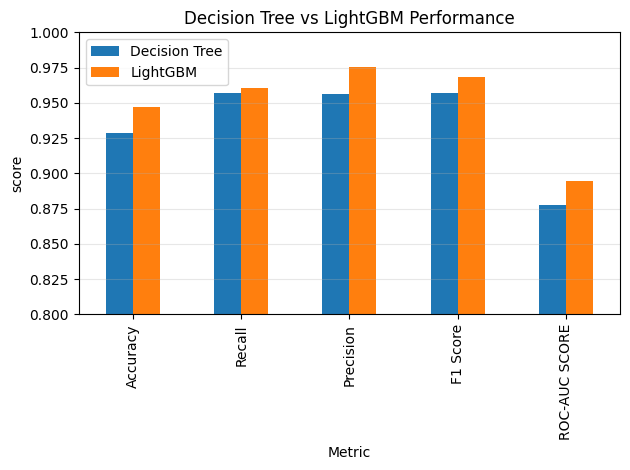

In [14]:
# SBA Loan Repayment Prediction

## Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgbm
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier

## Load Dataset

df = pd.read_csv("SBAnational2.csv")
df.head()


## Data Processing

# Drop rows where 'MIS_Status' is NaN to handle the ValueError
df.dropna(subset=['MIS_Status'], inplace=True)
print(f"Shape of DataFrame after dropping NaNs in 'MIS_Status': {df.shape}")

df["LowDoc"] = df["LowDoc"].map({"N": 0, "Y": 1})

x = df.drop(columns=["MIS_Status", "LoanStatus", "Bank"])
y = df["MIS_Status"]

x = pd.get_dummies(
    x,
    columns=["State", "BankState"],
    drop_first=True
)


## Train-Test Split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


## Decision Tree

tree_model = DecisionTreeClassifier(random_state=42, criterion="gini")
tree_model.fit(x_train, y_train)

tree_predictions = tree_model.predict(x_test)


## Decision Tree Evaluation

print("=== Decision Tree ===")
print(f"Accuracy: {accuracy_score(y_test, tree_predictions):.4f}")
print(f"Recall: {recall_score(y_test, tree_predictions):.4f}")
print(f"Precision: {precision_score(y_test, tree_predictions):.4f}")
print(f"F1 Score. {f1_score(y_test, tree_predictions):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, tree_predictions))


## Decision Tree Confusion matrix

cm = confusion_matrix(y_test, tree_predictions)

sns.heatmap(cm, annot=True, ftm="d", cmap="Blues")

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.savefig(
    "decision_tree_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## Decision Tree Feature Importance

feature_importances = pd.DataFrame({
    "Feature": x.columns,
    "Importance": tree_model.feature_importances_
})

feature_importances = feature_importances.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importances.head(20))

plt.figure(figsize=(10,6))
sns.barplot(
    data=feature_importances.head(20),
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Most Important Features")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    "decision_tree_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## LightGBM

lgbm_model = LGBMClassifier(random_state=42)
lgbm_model.fit(x_train, y_train)
lgbm_predictions = lgbm_model.predict(x_test)


## LightGBM Evaluation

print("=== LGBM ===")
print(f"Accuracy: {accuracy_score(y_test, lgbm_predictions):.4f}")
print(f"Recall: {recall_score(y_test, lgbm_predictions):.4f}")
print(f"Precision: {precision_score(y_test, lgbm_predictions):.4f}")
print(f"F1 Score: {f1_score(y_test, lgbm_predictions):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, lgbm_predictions))


## LightGBM Confusion Matrix

cm = confusion_matrix(y_test, lgbm_predictions)
sns.heatmap(cm, annot=True, ftm="d", cmap="Blues")
plt.title("LightGBM - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.savefig(
    "lightgbm_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## ROC-AUC Analysis

tree_probabilities = tree_model.predict_proba(x_test)[:,1]
lgbm_probabilities = lgbm_model.predict_proba(x_test)[:,1]

tree_auc = roc_auc_score(y_test, tree_probabilities)
lgbm_auc = roc_auc_score(y_test, lgbm_probabilities)

print(f"Decision Tree ROC-AUC: {tree_auc:.4f}")
print(f"LightGBM ROC-AUC: {lgbm_auc:.4f}")


## ROC CURVE

tree_fpr, tee_tpr, _ = roc_curve(y_test, tree_probabilities)
lgbm_fpr, lgbm_tpr, _ = roc_curve(y_test, lgbm_probabilities)

plt.figure(figsize=(8, 6))

plt.plot(tree_fpr, tee_tpr, label=f"Decision Tree AUC = {tree_auc:.4f}")

plt.plot(
    lgbm_fpr,
    lgbm_tpr,
    label=f"LightGBM (AUC = {lgbm_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.tight_layout()

plt.savefig(
    "roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



## Model Comparison

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Recall",
        "Precision",
        "F1 Score",
        "ROC-AUC"
    ],
    "Decision Tree": [
        accuracy_score(y_test, tree_predictions),
        recall_score(y_test, tree_predictions),
        precision_score(y_test, tree_predictions),
        f1_score(y_test, tree_predictions),
        tree_auc
    ],
    "LightGBM": [
        accuracy_score(y_test, lgbm_predictions),
        recall_score(y_test, lgbm_predictions),
        precision_score(y_test, lgbm_predictions),
        f1_score(y_test, lgbm_predictions),
        lgbm_auc
    ]
})

comparison


## Model Performance Comparison

comparison_plot = comparison.set_index("Metric")
plt.figure(figsize=(10,6))
comparison_plot.plot(kind="bar")

plt.title("Decision Tree vs LightGBM Performance")
plt.xlabel("Metric")
plt.ylabel("score")
plt.ylim(0.80, 1.00)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()


In [13]:
df.dropna(subset=['MIS_Status'], inplace=True)
print(f"Shape of DataFrame after dropping NaNs in 'MIS_Status': {df.shape}")

Shape of DataFrame after dropping NaNs in 'MIS_Status': (653656, 18)
